# Noisy QRC Analysis

Hamiltonian-style plotting for `Classical/results/exp1_6q_corr_noise` generated by `Classical/noisy_qrc_slurm.py`.

This notebook always plots aggregate metrics from `aggregate_summary_*.json`. Per-sample true-vs-predicted scatter and residual diagnostics require the matching `hardware_config_*.pkl` and `partials/<noise_label>/partial_iter*_*.pkl` artifacts because the aggregate JSON does not contain serialized predictions or ground-truth arrays.


In [7]:
from pathlib import Path
import json
import pickle
import sys
from dataclasses import fields

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
# Supports running from either the repository root or Classical/.
CWD = Path.cwd().resolve()
REPO_ROOT = CWD.parent if CWD.name == "Classical" else CWD
CLASSICAL_DIR = REPO_ROOT / "Classical" if (REPO_ROOT / "Classical").exists() else CWD
sys.path.insert(0, str(CLASSICAL_DIR))

RESULT_DIR = CLASSICAL_DIR / "results" / "exp1_6q_corr_noise"
PLOTS_DIR = RESULT_DIR / "plots"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

SUBSET_FRAC = 1.0  # Match noisy_qrc_slurm.py default unless the run used a smaller value.
SHORT_THRESHOLD = 64875

print(f"Result directory: {RESULT_DIR}")
print(f"Plots directory:  {PLOTS_DIR}")


Result directory: /Users/noah/repos/Icequake-QRC-/Classical/results/exp1_6q_corr_noise
Plots directory:  /Users/noah/repos/Icequake-QRC-/Classical/results/exp1_6q_corr_noise/plots


## Hamiltonian Manuscript Plot Style

The plotting functions below mirror the style of `Hamiltonian-QRC(Best).ipynb`: Arial labels where available, viridis absolute-error coloring clipped at the 95th percentile, short/long marker coding, diagonal reference line, and black panel borders.


In [8]:
def apply_hamiltonian_style():
    mpl.rcParams.update({
        "font.family": "Arial",
        "font.size": 11,
        "axes.labelsize": 11,
        "axes.titlesize": 11,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "legend.fontsize": 9,
        "axes.linewidth": 2.0,
        "axes.grid": False,
        "figure.dpi": 120,
        "savefig.dpi": 300,
        "savefig.bbox": "tight",
    })


def box_axes(ax):
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("black")
        spine.set_linewidth(2.0)


def regime_masks(y_true, threshold=SHORT_THRESHOLD):
    y_true = np.asarray(y_true)
    short_idx = y_true < threshold
    long_idx = ~short_idx
    return short_idx, long_idx


apply_hamiltonian_style()


## Discover Available Result Artifacts

The aggregate JSON is enough for summary metric plots. The pickle artifacts are required to reconstruct predictions because the JSON only stores ensemble metrics and per-iteration MAE values.


In [9]:
def load_aggregate_summaries(result_dir=RESULT_DIR):
    summaries = []
    for path in sorted(result_dir.glob("aggregate_summary*.json")):
        with path.open("r", encoding="utf-8") as f:
            payload = json.load(f)
        payload["_path"] = path
        summaries.append(payload)
    if not summaries:
        raise FileNotFoundError(f"No aggregate_summary*.json files found in {result_dir}")
    return summaries


def summary_file_tag(summary):
    noise_label = summary.get("noise_spec", {}).get("label", "unknown_noise")
    packing = summary.get("packing", {})
    packing_mode = packing.get("mode", "single")
    packing_label = packing.get("label", "single")
    return noise_label if packing_mode == "single" else f"{packing_label}_{noise_label}"


def expected_partials_dir(summary, result_dir=RESULT_DIR):
    noise_label = summary.get("noise_spec", {}).get("label", "")
    packing = summary.get("packing", {})
    packing_mode = packing.get("mode", "single")
    packing_label = packing.get("label", "single")
    if packing_mode == "single":
        return result_dir / "partials" / noise_label
    return result_dir / "partials" / f"pack_{packing_label}" / noise_label


def find_prediction_artifacts(summary, result_dir=RESULT_DIR):
    tag = summary_file_tag(summary)
    hardware_candidates = [result_dir / f"hardware_config_{tag}.pkl", result_dir / "hardware_config.pkl"]
    hardware_candidates.extend(sorted(result_dir.glob("hardware_config*.pkl")))
    hardware_path = next((p for p in hardware_candidates if p.exists()), None)

    partial_dir = expected_partials_dir(summary, result_dir)
    if not partial_dir.exists():
        noise_label = summary.get("noise_spec", {}).get("label", "")
        matches = sorted((result_dir / "partials").glob(f"**/{noise_label}/partial_iter*_short.pkl"))
        partial_dir = matches[0].parent if matches else partial_dir

    partial_files = sorted(partial_dir.glob("partial_iter*_*.pkl")) if partial_dir.exists() else []
    return {
        "tag": tag,
        "hardware_path": hardware_path,
        "partial_dir": partial_dir,
        "partial_files": partial_files,
        "has_prediction_artifacts": hardware_path is not None and len(partial_files) > 0,
    }


summaries = load_aggregate_summaries()
artifact_rows = []
for summary in summaries:
    artifacts = find_prediction_artifacts(summary)
    artifact_rows.append({
        "summary": summary["_path"].name,
        "tag": artifacts["tag"],
        "hardware_config": artifacts["hardware_path"].name if artifacts["hardware_path"] else None,
        "partials_dir": str(artifacts["partial_dir"].relative_to(RESULT_DIR)) if artifacts["partial_dir"].exists() else None,
        "partial_pickle_count": len(artifacts["partial_files"]),
        "can_reconstruct_predictions": artifacts["has_prediction_artifacts"],
    })

pd.DataFrame(artifact_rows)


,summary,tag,hardware_config,partials_dir,partial_pickle_count,can_reconstruct_predictions
0,aggregate_summary_pzz0.02_azz0_rc0_coupling.json,pzz0.02_azz0_rc0_coupling,hardware_config_pzz0.02_azz0_rc0_coupling.pkl,partials/pzz0.02_azz0_rc0_coupling,10,True


## Aggregate Metric Plots

These plots are available with the current artifact set. They summarize validation/test MAE by reservoir iteration and the ensemble metrics stored by `noisy_qrc_slurm.py`.


,tag,iteration,val_mae,test_mae,selected_top_k,ensemble_test_mae,ensemble_test_rmse,ensemble_test_r2
0,pzz0.02_azz0_rc0_coupling,0,10961.496640,9590.139591,True,9476.211607,17657.012905,0.231398
1,pzz0.02_azz0_rc0_coupling,1,11759.214619,9536.057097,False,9476.211607,17657.012905,0.231398
2,pzz0.02_azz0_rc0_coupling,2,11275.379314,9575.852537,True,9476.211607,17657.012905,0.231398
3,pzz0.02_azz0_rc0_coupling,3,10873.657574,9519.521785,True,9476.211607,17657.012905,0.231398
4,pzz0.02_azz0_rc0_coupling,4,11577.243816,9503.871450,False,9476.211607,17657.012905,0.231398


Wrote: /Users/noah/repos/Icequake-QRC-/Classical/results/exp1_6q_corr_noise/plots/aggregate_metrics_pzz0.02_azz0_rc0_coupling.png


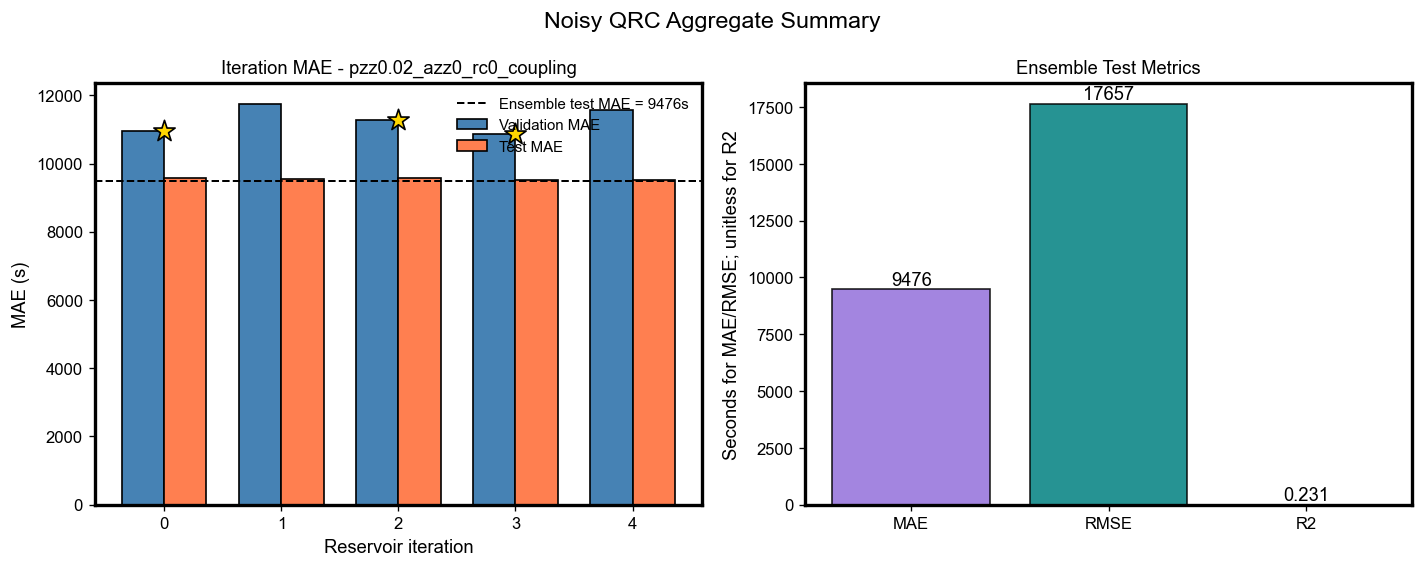

In [10]:
def summaries_to_frame(summaries):
    rows = []
    for summary in summaries:
        tag = summary_file_tag(summary)
        for idx, val_mae in enumerate(summary.get("per_iteration_val_mae", [])):
            test_mae = summary.get("per_iteration_test_mae", [np.nan] * (idx + 1))[idx]
            rows.append({
                "tag": tag,
                "iteration": idx,
                "val_mae": val_mae,
                "test_mae": test_mae,
                "selected_top_k": idx in set(summary.get("top_indices", [])),
                "ensemble_test_mae": summary.get("ensemble_test_mae", np.nan),
                "ensemble_test_rmse": summary.get("ensemble_test_rmse", np.nan),
                "ensemble_test_r2": summary.get("ensemble_test_r2", np.nan),
            })
    return pd.DataFrame(rows)


def plot_aggregate_metrics(summary, out_path=None):
    tag = summary_file_tag(summary)
    val = np.asarray(summary.get("per_iteration_val_mae", []), dtype=float)
    test = np.asarray(summary.get("per_iteration_test_mae", []), dtype=float)
    iterations = np.arange(len(val))
    top = set(summary.get("top_indices", []))

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
    width = 0.36
    axes[0].bar(iterations - width / 2, val, width, label="Validation MAE", color="steelblue", edgecolor="black")
    axes[0].bar(iterations + width / 2, test, width, label="Test MAE", color="coral", edgecolor="black")
    for idx in top:
        axes[0].scatter(idx, val[idx], marker="*", s=180, color="gold", edgecolor="black", zorder=5)
    axes[0].axhline(summary["ensemble_test_mae"], color="black", linestyle="--", linewidth=1.2,
                    label=f"Ensemble test MAE = {summary['ensemble_test_mae']:.0f}s")
    axes[0].set_xlabel("Reservoir iteration")
    axes[0].set_ylabel("MAE (s)")
    axes[0].set_title(f"Iteration MAE - {tag}")
    axes[0].legend(frameon=False)
    box_axes(axes[0])

    metric_names = ["MAE", "RMSE", "R2"]
    metric_values = [summary["ensemble_test_mae"], summary["ensemble_test_rmse"], summary["ensemble_test_r2"]]
    colors = ["mediumpurple", "teal", "grey"]
    axes[1].bar(metric_names, metric_values, color=colors, edgecolor="black", alpha=0.85)
    axes[1].set_title("Ensemble Test Metrics")
    axes[1].set_ylabel("Seconds for MAE/RMSE; unitless for R2")
    for i, value in enumerate(metric_values):
        label = f"{value:.3f}" if metric_names[i] == "R2" else f"{value:.0f}"
        axes[1].text(i, value, label, ha="center", va="bottom")
    box_axes(axes[1])

    fig.suptitle("Noisy QRC Aggregate Summary", fontsize=14)
    fig.tight_layout()
    if out_path is not None:
        fig.savefig(out_path)
    return fig


aggregate_df = summaries_to_frame(summaries)
display(aggregate_df)

for summary in summaries:
    out_path = PLOTS_DIR / f"aggregate_metrics_{summary_file_tag(summary)}.png"
    plot_aggregate_metrics(summary, out_path=out_path)
    print(f"Wrote: {out_path}")


## Prediction Reconstruction Helpers

Run this section only after the matching pickle artifacts are available. It follows the aggregation logic in `noisy_qrc_slurm.py`: load the saved classifier and top-k iteration settings, rebuild short/long hybrid features from partial Pauli matrices, retrain the stored XGBoost heads, route test samples, and average top-k predictions.


In [11]:
def require_prediction_artifacts(summary, result_dir=RESULT_DIR):
    artifacts = find_prediction_artifacts(summary, result_dir)
    if artifacts["has_prediction_artifacts"]:
        return artifacts

    raise FileNotFoundError(
        "Per-sample true-vs-predicted and residual plots cannot be reconstructed from "
        "aggregate_summary JSON alone. Add the matching hardware_config_*.pkl and "
        "partials/<noise_label>/partial_iter*_short.pkl + partial_iter*_long.pkl files.\n"
        f"Expected hardware config tag: hardware_config_{artifacts['tag']}.pkl\n"
        f"Expected partial directory: {artifacts['partial_dir']}"
    )


def build_config_from_hardware(hardware_cfg):
    from noisy_qrc_slurm import QRCConfig

    cfg_payload = hardware_cfg.get("pipeline_config", {})
    valid_names = {f.name for f in fields(QRCConfig)}
    kwargs = {k: v for k, v in cfg_payload.items() if k in valid_names}
    return QRCConfig(**kwargs)


def xgb_params_from_saved(saved_params, seed):
    params = {
        "objective": "reg:squarederror",
        "n_estimators": 1200,
        "random_state": seed,
        "early_stopping_rounds": 50,
        "tree_method": "hist",
    }
    params.update(saved_params)
    return params


def fit_saved_head(X_train, y_train, X_val, y_val, params):
    from xgboost import XGBRegressor

    model = XGBRegressor(**params)
    model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
    return model


def reconstruct_topk_predictions(summary, subset_frac=SUBSET_FRAC, result_dir=RESULT_DIR):
    from noisy_qrc_slurm import load_data, make_hybrid_features_decay

    artifacts = require_prediction_artifacts(summary, result_dir)
    with artifacts["hardware_path"].open("rb") as f:
        hardware_cfg = pickle.load(f)

    cfg = build_config_from_hardware(hardware_cfg)
    threshold = hardware_cfg.get("short_threshold", cfg.short_threshold)
    top_indices = list(hardware_cfg.get("top_k_indices", summary.get("top_indices", [])))
    if not top_indices:
        raise ValueError("No top_k_indices found in hardware config or summary")

    X_train_q, X_val_q, X_test_q, y_train, y_val, y_test, *_ = load_data(cfg, subset_frac)
    clf = hardware_cfg["regime_classifier"]
    clf_test_labels = clf.predict(X_test_q)

    short_mask_train = y_train < threshold
    long_mask_train = ~short_mask_train
    short_mask_val = y_val < threshold
    long_mask_val = ~short_mask_val
    short_test_idx = np.where(clf_test_labels == 0)[0]
    long_test_idx = np.where(clf_test_labels == 1)[0]

    n_total_events = cfg.n_previous_events + 1
    n_obs = 4 * cfg.n_qubits
    preds = []

    for iter_idx in top_indices:
        short_path = artifacts["partial_dir"] / f"partial_iter{iter_idx}_short.pkl"
        long_path = artifacts["partial_dir"] / f"partial_iter{iter_idx}_long.pkl"
        if not short_path.exists() or not long_path.exists():
            raise FileNotFoundError(f"Missing partial pair for iteration {iter_idx}: {short_path}, {long_path}")
        with short_path.open("rb") as f:
            ps = pickle.load(f)
        with long_path.open("rb") as f:
            pl = pickle.load(f)

        H_tr_short = make_hybrid_features_decay(ps["P_train"], n_total_events, n_obs)
        H_vl_short = make_hybrid_features_decay(ps["P_val"], n_total_events, n_obs)
        H_te_short = make_hybrid_features_decay(ps["P_test"], n_total_events, n_obs)
        H_tr_long = make_hybrid_features_decay(pl["P_train"], n_total_events, n_obs)
        H_vl_long = make_hybrid_features_decay(pl["P_val"], n_total_events, n_obs)
        H_te_long = make_hybrid_features_decay(pl["P_test"], n_total_events, n_obs)

        saved_params = hardware_cfg["xgb_params_per_iteration"].get(iter_idx) or hardware_cfg["xgb_params_per_iteration"].get(str(iter_idx))
        if saved_params is None:
            raise KeyError(f"No saved XGBoost params for iteration {iter_idx}")

        model_short = fit_saved_head(
            H_tr_short, y_train[short_mask_train], H_vl_short, y_val[short_mask_val],
            xgb_params_from_saved(saved_params["short"], cfg.random_seed + iter_idx),
        )
        model_long = fit_saved_head(
            H_tr_long, y_train[long_mask_train], H_vl_long, y_val[long_mask_val],
            xgb_params_from_saved(saved_params["long"], cfg.random_seed + iter_idx + 1),
        )

        pred = np.empty(len(y_test), dtype=float)
        if len(short_test_idx):
            pred[short_test_idx] = model_short.predict(H_te_short)
        if len(long_test_idx):
            pred[long_test_idx] = model_long.predict(H_te_long)
        preds.append(pred)

    ensemble_pred = np.mean(preds, axis=0)
    return y_test, ensemble_pred, np.asarray(top_indices), clf_test_labels


## Hamiltonian-Style True-vs-Predicted and Diagnostics

The next cell intentionally requires pickle artifacts. With the current repository contents, it will explain exactly what is missing instead of fabricating scatter or residual plots from aggregate metrics.


X shape:  (2822, 126)
y shape:  (2822,)
{'mae': 9483.48215684919, 'rmse': 17651.330103092885, 'r2': 0.23189264008274402, 'median_absolute_error': 3198.6536458333358, 'max_absolute_error': 70006.69270833334, 'top_indices': [3, 0, 2]}
Wrote: /Users/noah/repos/Icequake-QRC-/Classical/results/exp1_6q_corr_noise/plots/true_vs_pred_pzz0.02_azz0_rc0_coupling.png
Wrote: /Users/noah/repos/Icequake-QRC-/Classical/results/exp1_6q_corr_noise/plots/diagnostics_pzz0.02_azz0_rc0_coupling.png


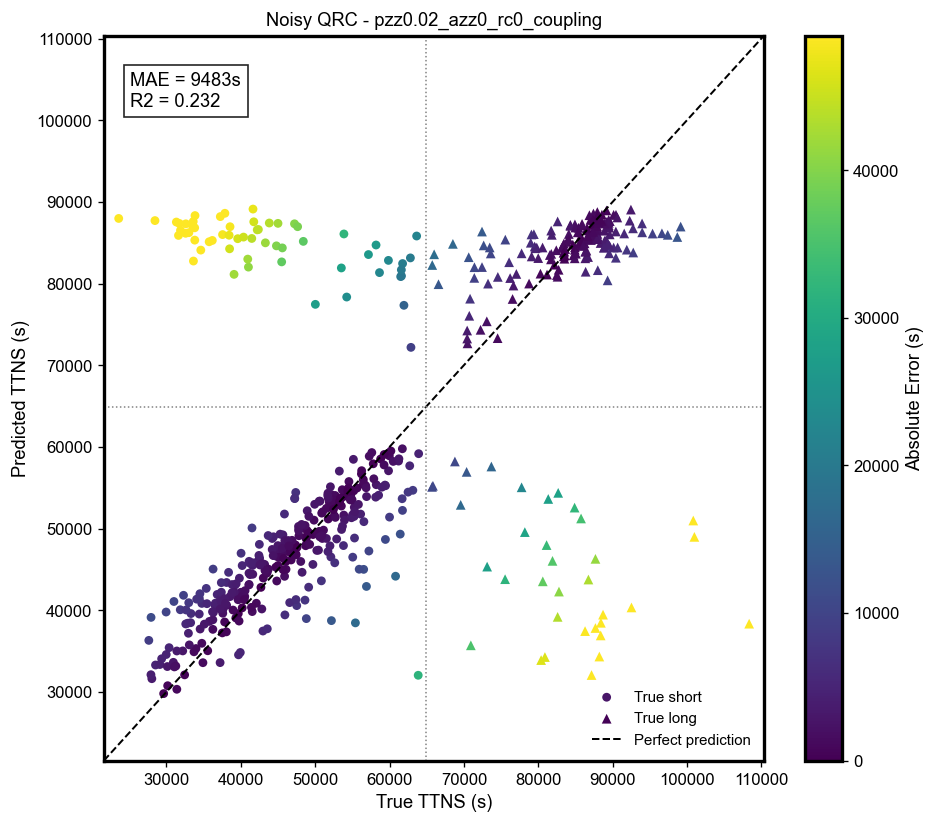

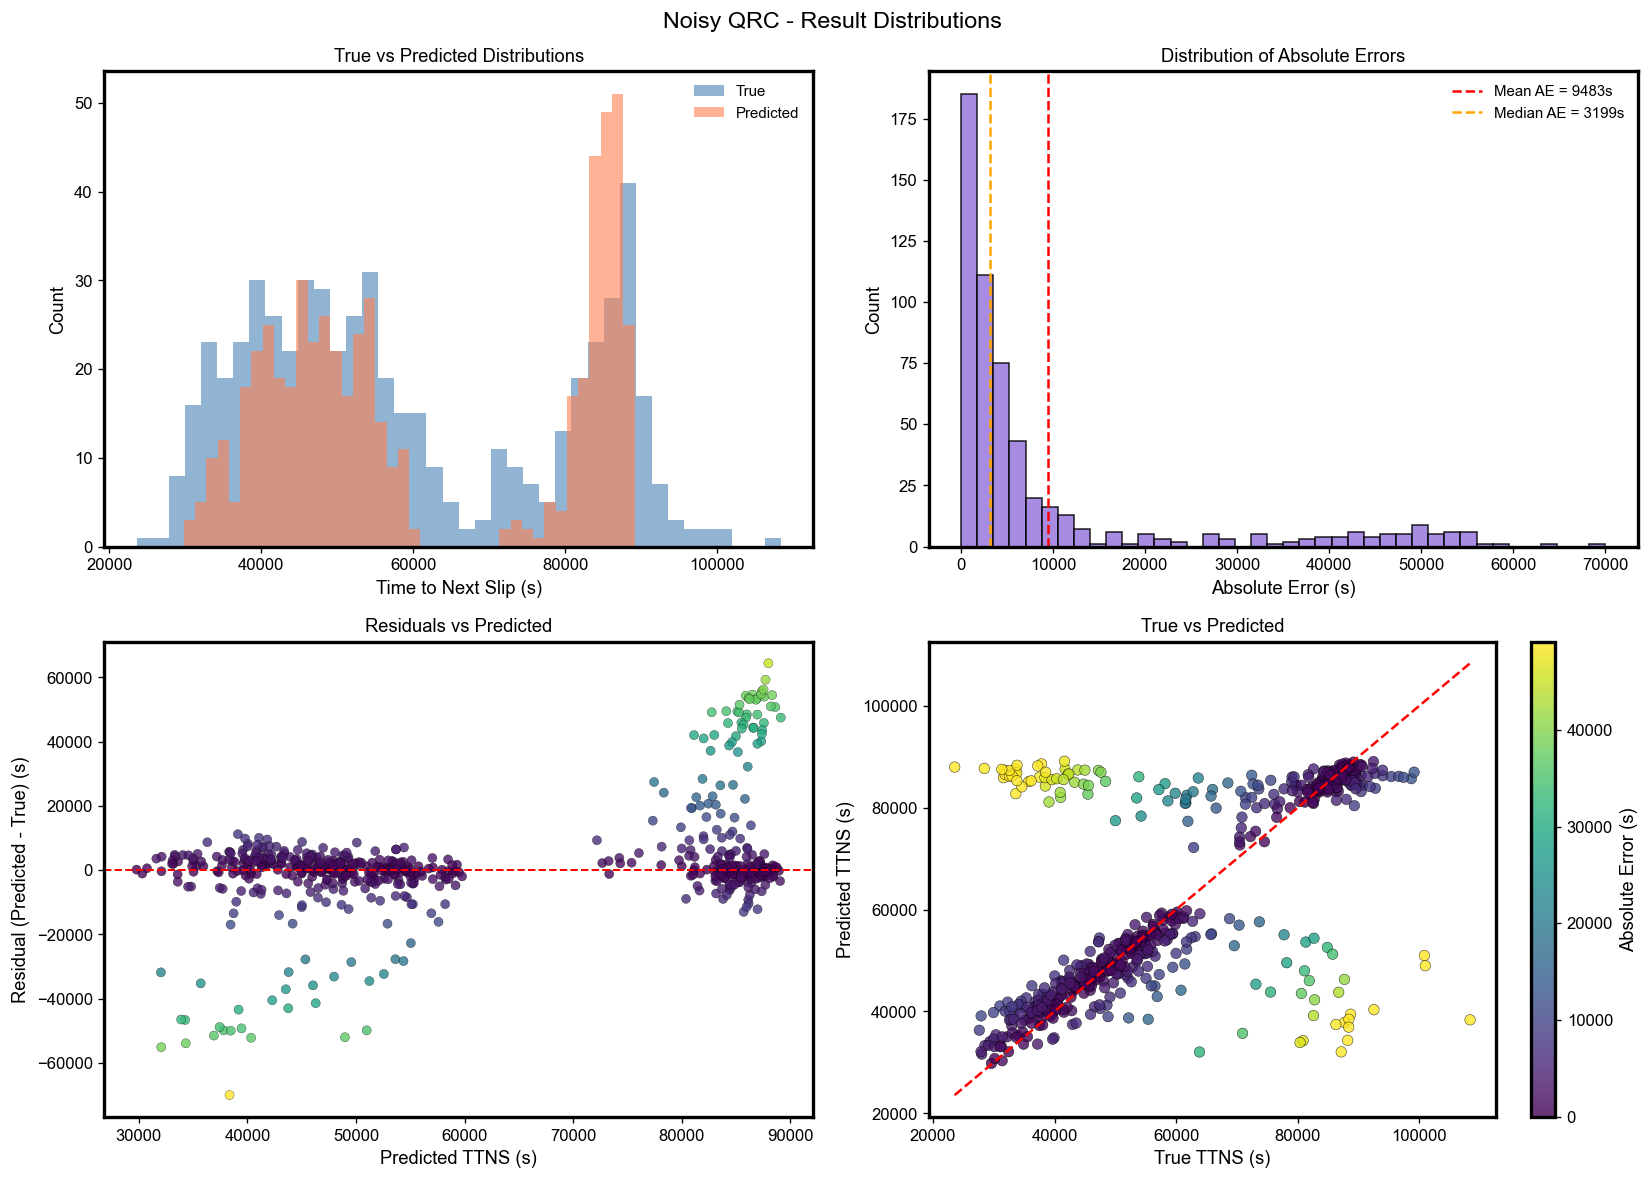

In [12]:
def plot_true_vs_pred_hamiltonian(y_true, y_pred, title, out_path=None, threshold=SHORT_THRESHOLD):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    abs_err = np.abs(y_pred - y_true)
    short_idx, long_idx = regime_masks(y_true, threshold)
    all_vals = np.concatenate([y_true, y_pred])
    ax_min = max(0, np.min(all_vals) - 2_000)
    ax_max = np.max(all_vals) + 2_000
    norm = mpl.colors.Normalize(vmin=0, vmax=np.percentile(abs_err, 95))

    fig, ax = plt.subplots(figsize=(8, 7))
    sc = ax.scatter(y_true[short_idx], y_pred[short_idx], c=abs_err[short_idx], cmap="viridis", norm=norm,
                    s=28, marker="o", edgecolors="none", label="True short")
    ax.scatter(y_true[long_idx], y_pred[long_idx], c=abs_err[long_idx], cmap="viridis", norm=norm,
               s=34, marker="^", edgecolors="none", label="True long")
    ax.plot([ax_min, ax_max], [ax_min, ax_max], "k--", linewidth=1.2, label="Perfect prediction")
    ax.axvline(threshold, color="grey", linestyle=":", linewidth=0.9)
    ax.axhline(threshold, color="grey", linestyle=":", linewidth=0.9)
    ax.set_xlim(ax_min, ax_max)
    ax.set_ylim(ax_min, ax_max)
    ax.set_xlabel("True TTNS (s)")
    ax.set_ylabel("Predicted TTNS (s)")
    ax.set_title(title)
    ax.text(0.04, 0.95, f"MAE = {mean_absolute_error(y_true, y_pred):.0f}s\nR2 = {r2_score(y_true, y_pred):.3f}",
            transform=ax.transAxes, va="top", ha="left",
            bbox=dict(facecolor="white", edgecolor="black", alpha=0.85))
    ax.legend(frameon=False, loc="lower right")
    box_axes(ax)
    fig.colorbar(sc, ax=ax, label="Absolute Error (s)")
    fig.tight_layout()
    if out_path is not None:
        fig.savefig(out_path)
    return fig


def plot_diagnostics_panel(y_true, y_pred, title, out_path=None):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    abs_err = np.abs(y_pred - y_true)
    residuals = y_pred - y_true

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(title, fontsize=14)

    axes[0, 0].hist(y_true, bins=40, alpha=0.6, color="steelblue", label="True")
    axes[0, 0].hist(y_pred, bins=40, alpha=0.6, color="coral", label="Predicted")
    axes[0, 0].set_xlabel("Time to Next Slip (s)")
    axes[0, 0].set_ylabel("Count")
    axes[0, 0].set_title("True vs Predicted Distributions")
    axes[0, 0].legend(frameon=False)

    axes[0, 1].hist(abs_err, bins=40, color="mediumpurple", edgecolor="black", alpha=0.8)
    axes[0, 1].axvline(abs_err.mean(), color="red", linestyle="--", label=f"Mean AE = {abs_err.mean():.0f}s")
    axes[0, 1].axvline(np.median(abs_err), color="orange", linestyle="--", label=f"Median AE = {np.median(abs_err):.0f}s")
    axes[0, 1].set_xlabel("Absolute Error (s)")
    axes[0, 1].set_ylabel("Count")
    axes[0, 1].set_title("Distribution of Absolute Errors")
    axes[0, 1].legend(frameon=False)

    axes[1, 0].scatter(y_pred, residuals, c=abs_err, cmap="viridis", s=30, edgecolors="black", linewidths=0.2, alpha=0.8)
    axes[1, 0].axhline(0, color="red", linestyle="--", linewidth=1.2)
    axes[1, 0].set_xlabel("Predicted TTNS (s)")
    axes[1, 0].set_ylabel("Residual (Predicted - True) (s)")
    axes[1, 0].set_title("Residuals vs Predicted")

    norm = mpl.colors.Normalize(vmin=0, vmax=np.percentile(abs_err, 95))
    sc = axes[1, 1].scatter(y_true, y_pred, c=abs_err, cmap="viridis", norm=norm,
                            s=40, edgecolors="black", linewidths=0.3, alpha=0.8)
    axes[1, 1].plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], "r--", linewidth=1.5)
    axes[1, 1].set_xlabel("True TTNS (s)")
    axes[1, 1].set_ylabel("Predicted TTNS (s)")
    axes[1, 1].set_title("True vs Predicted")
    fig.colorbar(sc, ax=axes[1, 1], label="Absolute Error (s)")

    for ax in axes.ravel():
        box_axes(ax)
    fig.tight_layout()
    if out_path is not None:
        fig.savefig(out_path)
    return {
        "mae": float(mean_absolute_error(y_true, y_pred)),
        "rmse": float(root_mean_squared_error(y_true, y_pred)),
        "r2": float(r2_score(y_true, y_pred)),
        "median_absolute_error": float(np.median(abs_err)),
        "max_absolute_error": float(abs_err.max()),
    }


summary = summaries[0]
y_test, noisy_pred, top_indices, routed_labels = reconstruct_topk_predictions(summary)
scatter_path = PLOTS_DIR / f"true_vs_pred_{summary_file_tag(summary)}.png"
panel_path = PLOTS_DIR / f"diagnostics_{summary_file_tag(summary)}.png"
plot_true_vs_pred_hamiltonian(y_test, noisy_pred, f"Noisy QRC - {summary_file_tag(summary)}", scatter_path)
metrics = plot_diagnostics_panel(y_test, noisy_pred, "Noisy QRC - Result Distributions", panel_path)
metrics["top_indices"] = top_indices.tolist()
print(metrics)
print(f"Wrote: {scatter_path}")
print(f"Wrote: {panel_path}")
